# 00 — Math Foundations of 3D Gaussian Splatting

Notebook này là **Phase 0** của project `Adaptive 3D Gaussian Splatting`.

Mục tiêu:

1. Hiểu biểu diễn một 3D Gaussian:
   \[
   G_i=(\mu_i,\Sigma_i,\alpha_i,SH_i)
   \]
2. Parameterize covariance bằng scale + quaternion rotation:
   \[
   \Sigma = R S S^T R^T
   \]
3. Thực hiện world → camera → screen projection.
4. Tính screen-space covariance bằng Jacobian:
   \[
   \Sigma_{2D}=J\,W\,\Sigma\,W^T\,J^T
   \]
5. Kiểm tra các tính chất toán học bằng unit tests.
6. Visualize 2D ellipse của Gaussian sau projection.

> Notebook này **chưa implement renderer/rasterizer**. Nó chỉ xác nhận phần toán học cần thiết trước khi sang Phase 1.

## 0. Environment

Project dependencies tối thiểu:

- Python 3
- PyTorch
- NumPy
- Matplotlib

Kiểm tra trước khi chạy toàn bộ notebook.

In [16]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import math
print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("NumPy  :", np.__version__)
print("CUDA available:", torch.cuda.is_available())

torch.set_printoptions(precision=5, sci_mode=False)

Python : 3.13.15
PyTorch: 2.11.0+cpu
NumPy  : 2.1.3
CUDA available: False


# 1. 3D Gaussian Representation

Một Gaussian trong project có thể được biểu diễn bởi:

- `mu`: vị trí 3D, shape `[3]`
- `Sigma`: covariance, shape `[3, 3]`
- `alpha`: opacity
- `SH`: appearance/view-dependent coefficients

Ở Phase 0, ta tập trung vào `mu` và `Sigma`.

In [4]:
# Một Gaussian toy
mu = torch.tensor([0.0, 0.0, 3.0], dtype=torch.float32)

alpha = torch.tensor(0.99, dtype=torch.float32)

# Covariance identity là Gaussian hình cầu đơn giản
Sigma_identity = torch.eye(3)

print("mu =", mu)
print("Sigma =\n", Sigma_identity)
print("alpha =", alpha)

mu = tensor([0., 0., 3.])
Sigma =
 tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
alpha = tensor(0.99000)


## 1.1 Covariance và hình ellipsoid

Contour của Gaussian có thể được mô tả bằng khoảng cách Mahalanobis:

\[
(x-\mu)^T \Sigma^{-1}(x-\mu)=1
\]

Nếu `Sigma` là SPD (symmetric positive definite), contour này tạo thành một ellipsoid hợp lệ.

Vì vậy một yêu cầu quan trọng là covariance phải luôn hợp lệ.

In [5]:
def is_symmetric(A, atol=1e-5):
    return torch.allclose(A, A.T, atol=atol)

def is_spd(A, atol=1e-7):
    # Eigenvalues của ma trận đối xứng SPD phải dương
    eigvals = torch.linalg.eigvalsh(A)
    return is_symmetric(A) and torch.all(eigvals > atol)

print("Symmetric:", is_symmetric(Sigma_identity))
print("SPD      :", is_spd(Sigma_identity))
print("Eigenvalues:", torch.linalg.eigvalsh(Sigma_identity))

Symmetric: True
SPD      : tensor(True)
Eigenvalues: tensor([1., 1., 1.])


# 2. Stable Covariance Parameterization

Thay vì học trực tiếp 9 phần tử của `Sigma`, project dùng:

\[
\Sigma = R S S^T R^T
\]

với:

- `S`: scale matrix
- `R`: rotation matrix

Để scale luôn dương, ta parameterize:

\[
s_k=\exp(l_k)
\]

và:

\[
S=\operatorname{diag}(\exp(l_1),\exp(l_2),\exp(l_3))
\]

Rotation dùng quaternion để tránh phải optimize trực tiếp ma trận rotation.

In [6]:
def make_scale_matrix(log_scale):
    """log_scale: [3] -> positive diagonal scale matrix [3,3]."""
    scale = torch.exp(log_scale)
    return torch.diag(scale)

log_scale = torch.tensor([0.0, -0.2, -1.0])
S = make_scale_matrix(log_scale)

print("log_scale =", log_scale)
print("scale     =", torch.exp(log_scale))
print("S =\n", S)

log_scale = tensor([ 0.00000, -0.20000, -1.00000])
scale     = tensor([1.00000, 0.81873, 0.36788])
S =
 tensor([[1.00000, 0.00000, 0.00000],
        [0.00000, 0.81873, 0.00000],
        [0.00000, 0.00000, 0.36788]])


## 2.1 Quaternion → Rotation Matrix

Ta lưu quaternion:

\[
q=(w,x,y,z)
\]

và normalize:

\[
\hat q=\frac{q}{\|q\|}
\]

sau đó chuyển sang rotation matrix.

Điểm quan trọng của notebook là kiểm tra:

\[
R^TR \approx I
\]

và:

\[
\det(R)\approx 1
\]

In [7]:
def normalize_quaternion(q, eps=1e-12):
    return q / torch.linalg.vector_norm(q).clamp_min(eps)


def quaternion_to_rotation_matrix(q):
    """
    q = [w, x, y, z]
    Returns R [3,3].
    """
    q = normalize_quaternion(q)
    w, x, y, z = q

    R = torch.stack([
        1 - 2*(y*y + z*z),
        2*(x*y - z*w),
        2*(x*z + y*w),

        2*(x*y + z*w),
        1 - 2*(x*x + z*z),
        2*(y*z - x*w),

        2*(x*z - y*w),
        2*(y*z + x*w),
        1 - 2*(x*x + y*y),
    ]).reshape(3, 3)

    return R


q = torch.tensor([0.9238795, 0.0, 0.3826834, 0.0])
R = quaternion_to_rotation_matrix(q)

print("R =\n", R)
print("R^T R =\n", R.T @ R)
print("det(R) =", torch.linalg.det(R))

R =
 tensor([[ 0.70711,  0.00000,  0.70711],
        [ 0.00000,  1.00000,  0.00000],
        [-0.70711,  0.00000,  0.70711]])
R^T R =
 tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
det(R) = tensor(1.)


## 2.2 Build covariance from scale + rotation

\[
\Sigma = RSS^TR^T
\]

Do not optimize `Sigma` directly trong implementation chính. Ta học `log_scale` và quaternion rồi dựng `Sigma`.

In [8]:
def covariance_from_scale_quaternion(log_scale, quaternion):
    S = make_scale_matrix(log_scale)
    R = quaternion_to_rotation_matrix(quaternion)
    Sigma = R @ S @ S.T @ R.T
    return Sigma


Sigma = covariance_from_scale_quaternion(log_scale, q)

print("Sigma =\n", Sigma)
print("Symmetric:", is_symmetric(Sigma))
print("SPD      :", is_spd(Sigma))
print("Eigenvalues:", torch.linalg.eigvalsh(Sigma))

Sigma =
 tensor([[ 0.56767,  0.00000, -0.43233],
        [ 0.00000,  0.67032,  0.00000],
        [-0.43233,  0.00000,  0.56767]])
Symmetric: True
SPD      : tensor(True)
Eigenvalues: tensor([0.13534, 0.67032, 1.00000])


## 2.3 Unit test: rotation và covariance

Các invariant cần giữ:

- `R.T @ R = I`
- `det(R) = 1`
- `Sigma = Sigma.T`
- eigenvalues(`Sigma`) > 0

In [9]:
I = torch.eye(3)

assert torch.allclose(R.T @ R, I, atol=1e-5)
assert torch.allclose(torch.linalg.det(R), torch.tensor(1.0), atol=1e-5)
assert torch.allclose(Sigma, Sigma.T, atol=1e-5)
assert is_spd(Sigma)

print("All rotation/covariance tests passed.")

All rotation/covariance tests passed.


# 3. Camera Geometry

Ta dùng pipeline:

```text
world point
    ↓
camera transform
    ↓
perspective projection
    ↓
pixel coordinates
```

Camera transform:

\[
x_c = W x
\]

Trong đó ở đây `W` là rotation + translation của world → camera.

Ta dùng tọa độ camera:

\[
x_c=(x,y,z)
\]

với `z > 0` cho điểm nằm trước camera.

In [10]:
def world_to_camera(points_world, R_wc, t_wc):
    """
    points_world: [...,3]
    R_wc: [3,3]
    t_wc: [3]

    x_cam = R_wc @ x_world + t_wc
    """
    return (points_world @ R_wc.T) + t_wc


# Camera tại origin, không rotation
R_wc = torch.eye(3)
t_wc = torch.zeros(3)

point_world = torch.tensor([[0.0, 0.0, 3.0]])
point_camera = world_to_camera(point_world, R_wc, t_wc)

print("world :", point_world)
print("camera:", point_camera)

world : tensor([[0., 0., 3.]])
camera: tensor([[0., 0., 3.]])


# 4. Perspective Projection

Với intrinsic matrix:

\[
K=
\begin{bmatrix}
f_x&0&c_x\\
0&f_y&c_y\\
0&0&1
\end{bmatrix}
\]

Perspective projection:

\[
u=f_x\frac{x}{z}+c_x
\]

\[
v=f_y\frac{y}{z}+c_y
\]

Ta sẽ dùng một camera toy để dễ visualize.

In [11]:
def project_points(points_camera, fx, fy, cx, cy, eps=1e-8):
    x = points_camera[..., 0]
    y = points_camera[..., 1]
    z = points_camera[..., 2].clamp_min(eps)

    u = fx * x / z + cx
    v = fy * y / z + cy

    return torch.stack([u, v], dim=-1)


fx, fy = 500.0, 500.0
cx, cy = 320.0, 240.0

uv = project_points(point_camera, fx, fy, cx, cy)

print("pixel:", uv)

pixel: tensor([[320., 240.]])


# 5. Jacobian of Perspective Projection

Đây là phần nối geometry với differentiable splatting.

Với:

\[
u=f_x\frac{x}{z}+c_x,
\qquad
v=f_y\frac{y}{z}+c_y
\]

Jacobian theo `(x,y,z)` là:

\[
J=
\begin{bmatrix}
f_x/z & 0 & -f_xx/z^2 \\
0 & f_y/z & -f_yy/z^2
\end{bmatrix}
\]

Sau đó screen-space covariance:

\[
\Sigma_{2D}
=
J W \Sigma W^T J^T
\]

Ở đây `W` chính là phần rotation world → camera khi propagation covariance.

In [12]:
def perspective_jacobian(point_camera, fx, fy, eps=1e-8):
    x, y, z = point_camera
    z = z.clamp_min(eps)

    J = torch.stack([
        torch.stack([fx / z, torch.tensor(0.0, dtype=z.dtype), -fx * x / (z*z)]),
        torch.stack([torch.tensor(0.0, dtype=z.dtype), fy / z, -fy * y / (z*z)]),
    ])

    return J


J = perspective_jacobian(point_camera[0], fx, fy)
print("J =\n", J)

J =
 tensor([[166.66667,   0.00000,  -0.00000],
        [  0.00000, 166.66667,  -0.00000]])


## 5.1 Screen-space covariance

Chú ý:

- `Sigma` là covariance trong world coordinates.
- `R_wc @ Sigma @ R_wc.T` đưa covariance sang camera coordinates.
- `J` linearize phép perspective projection tại Gaussian center.
- Kết quả là một covariance `2x2` trên image plane.

In [13]:
def screen_space_covariance(Sigma_world, R_wc, point_camera, fx, fy):
    Sigma_camera = R_wc @ Sigma_world @ R_wc.T
    J = perspective_jacobian(point_camera, fx, fy)

    Sigma_2d = J @ Sigma_camera @ J.T
    return Sigma_2d


Sigma_2d = screen_space_covariance(
    Sigma_world=Sigma,
    R_wc=R_wc,
    point_camera=point_camera[0],
    fx=fx,
    fy=fy,
)

print("Sigma_2D =\n", Sigma_2d)
print("Symmetric:", is_symmetric(Sigma_2d))
print("Eigenvalues:", torch.linalg.eigvalsh(Sigma_2d))

Sigma_2D =
 tensor([[15768.54883,     0.00000],
        [    0.00000, 18620.00391]])
Symmetric: True
Eigenvalues: tensor([15768.54883, 18620.00391])


## 5.2 Unit test cho screen-space covariance

Với covariance 3D SPD và Jacobian có full row rank trong vùng camera hợp lệ, screen-space covariance phải symmetric positive definite (trong trường hợp non-degenerate).

Đây là invariant quan trọng trước khi xây ellipse/rasterizer.

In [14]:
assert torch.allclose(Sigma_2d, Sigma_2d.T, atol=1e-5)
assert is_spd(Sigma_2d)

print("Screen-space covariance test passed.")

Screen-space covariance test passed.


# 6. Visualize the Projected Gaussian Ellipse

Một Gaussian sau projection tạo ra elliptical footprint.

Với:

\[
d^T\Sigma_{2D}^{-1}d = 1
\]

ta có contour ellipse.

Ta dùng eigen-decomposition:

\[
\Sigma_{2D}=V\Lambda V^T
\]

- eigenvectors → hướng chính
- eigenvalues → bình phương độ lớn các trục

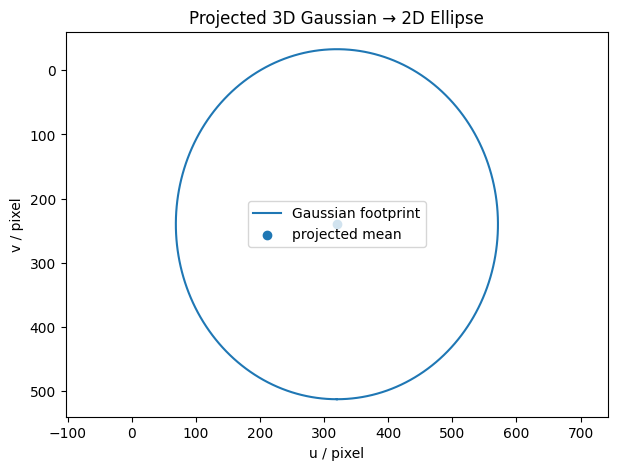

2D eigenvalues: tensor([18620.00391, 15768.54883])


In [17]:
def ellipse_points(mean_2d, covariance_2d, n=200, scale=1.0):
    eigvals, eigvecs = torch.linalg.eigh(covariance_2d)

    # eigenvalues tăng dần -> đảo để trục chính đứng trước
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    theta = torch.linspace(0, 2 * math.pi, n)
    circle = torch.stack([torch.cos(theta), torch.sin(theta)])

    axes = torch.diag(torch.sqrt(eigvals)) * scale
    ellipse = (eigvecs @ axes @ circle) + mean_2d[:, None]

    return ellipse.T, eigvals, eigvecs


mean_2d = uv[0]
ellipse, eigvals_2d, eigvecs_2d = ellipse_points(mean_2d, Sigma_2d, scale=2.0)

plt.figure(figsize=(7, 5))
plt.plot(ellipse[:, 0].numpy(), ellipse[:, 1].numpy(), label="Gaussian footprint")
plt.scatter([mean_2d[0]], [mean_2d[1]], label="projected mean")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.xlabel("u / pixel")
plt.ylabel("v / pixel")
plt.title("Projected 3D Gaussian → 2D Ellipse")
plt.legend()
plt.show()

print("2D eigenvalues:", eigvals_2d)

# 7. A More Realistic Rotated + Anisotropic Gaussian

Bây giờ thay Gaussian hình gần cầu bằng một Gaussian anisotropic:

- scale X lớn
- scale Y trung bình
- scale Z nhỏ
- có rotation

Ta sẽ xem ellipse thay đổi như thế nào trên màn hình.

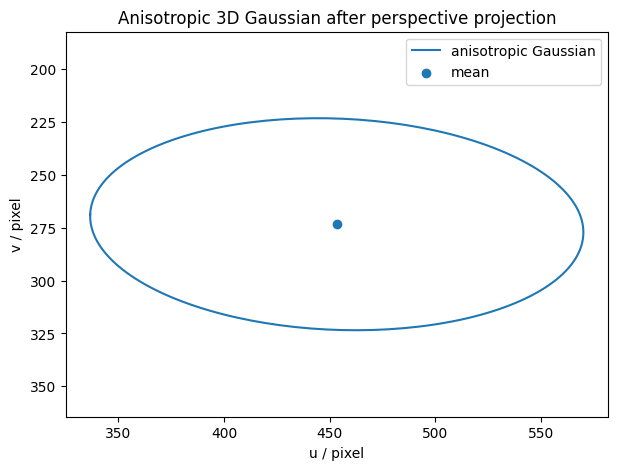

Sigma_demo =
 tensor([[ 0.09250,  0.00000, -0.05196],
        [ 0.00000,  0.02250,  0.00000],
        [-0.05196,  0.00000,  0.03250]])
Sigma_demo_2D =
 tensor([[3403.44287,  112.27444],
        [ 112.27444,  629.01233]])
2D eigenvalues: tensor([3407.97900,  624.47626])


In [18]:
log_scale_demo = torch.log(torch.tensor([0.35, 0.15, 0.05]))
q_demo = torch.tensor([0.9659258, 0.0, 0.2588190, 0.0])  # ~30° rotation

Sigma_demo = covariance_from_scale_quaternion(log_scale_demo, q_demo)

point_demo_world = torch.tensor([[0.8, 0.2, 3.0]])
point_demo_cam = world_to_camera(point_demo_world, R_wc, t_wc)
uv_demo = project_points(point_demo_cam, fx, fy, cx, cy)

Sigma_demo_2d = screen_space_covariance(
    Sigma_world=Sigma_demo,
    R_wc=R_wc,
    point_camera=point_demo_cam[0],
    fx=fx,
    fy=fy,
)

ellipse_demo, eig_demo, _ = ellipse_points(
    uv_demo[0],
    Sigma_demo_2d,
    scale=2.0
)

plt.figure(figsize=(7, 5))
plt.plot(
    ellipse_demo[:, 0].numpy(),
    ellipse_demo[:, 1].numpy(),
    label="anisotropic Gaussian"
)
plt.scatter([uv_demo[0, 0]], [uv_demo[0, 1]], label="mean")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.xlabel("u / pixel")
plt.ylabel("v / pixel")
plt.title("Anisotropic 3D Gaussian after perspective projection")
plt.legend()
plt.show()

print("Sigma_demo =\n", Sigma_demo)
print("Sigma_demo_2D =\n", Sigma_demo_2d)
print("2D eigenvalues:", eig_demo)

# 8. Autograd Sanity Check

3DGS optimization cần differentiability.

Ta kiểm tra gradient:

\[
\frac{\partial L}{\partial \mu},
\qquad
\frac{\partial L}{\partial l},
\qquad
\frac{\partial L}{\partial q}
\]

Thông qua PyTorch autograd.

Ở đây ta chưa optimize một scene; chỉ kiểm tra gradient có tồn tại và finite.

In [19]:
mu_train = torch.tensor([0.2, -0.1, 3.0], requires_grad=True)
log_scale_train = torch.tensor(
    [0.0, -0.4, -0.8],
    requires_grad=True
)
q_train = torch.tensor(
    [1.0, 0.1, 0.2, -0.1],
    requires_grad=True
)

Sigma_train = covariance_from_scale_quaternion(
    log_scale_train,
    q_train
)

R_train = quaternion_to_rotation_matrix(q_train)
point_cam_train = world_to_camera(
    mu_train[None, :],
    R_wc,
    t_wc
)[0]

uv_train = project_points(
    point_cam_train[None, :],
    fx, fy, cx, cy
)[0]

Sigma_2d_train = screen_space_covariance(
    Sigma_train,
    R_wc,
    point_cam_train,
    fx,
    fy
)

# Toy scalar loss: muốn projected center gần target và footprint nhỏ
target_uv = torch.tensor([350.0, 220.0])
loss = (
    torch.sum((uv_train - target_uv)**2)
    + 0.01 * torch.trace(Sigma_2d_train)
)

loss.backward()

print("Loss:", float(loss))
print("grad mu       =", mu_train.grad)
print("grad log_scale=", log_scale_train.grad)
print("grad quat     =", q_train.grad)

assert torch.isfinite(mu_train.grad).all()
assert torch.isfinite(log_scale_train.grad).all()
assert torch.isfinite(q_train.grad).all()

print("Autograd sanity check passed.")

Loss: 400.79974365234375
grad mu       = tensor([1166.69397, 1093.56006, -293.71259])
grad log_scale= tensor([497.61679, 245.25098,  14.28713])
grad quat     = tensor([  57.60578,  -53.49202, -258.62903,    5.30766])
Autograd sanity check passed.


/tmp/ipykernel_709/1091790367.py:45: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Loss:", float(loss))


# 9. Numerical Stress Tests

Các trường hợp cần chú ý:

1. Quaternion gần zero.
2. `z` quá nhỏ.
3. Scale rất nhỏ/lớn.
4. Degenerate projection.

Notebook này dùng epsilon để tránh chia 0.

Trong renderer thật, Gaussian phía sau camera hoặc Gaussian có footprint quá nhỏ/lớn phải được culling/clamping ở layer thích hợp.

In [20]:
# Quaternion gần zero vẫn được normalize nhờ clamp
q_small = torch.tensor([1e-12, 1e-12, 0.0, 0.0])
R_small = quaternion_to_rotation_matrix(q_small)

print("R_small =\n", R_small)
print("det(R_small) =", torch.linalg.det(R_small))

assert torch.isfinite(R_small).all()

# Point có z nhỏ nhưng dương
point_near = torch.tensor([0.2, 0.1, 1e-4])
uv_near = project_points(point_near[None], fx, fy, cx, cy)

print("near-camera projection:", uv_near)
assert torch.isfinite(uv_near).all()

R_small =
 tensor([[ 1.00000,  0.00000,  0.00000],
        [ 0.00000,  0.00000, -1.00000],
        [ 0.00000,  1.00000,  0.00000]])
det(R_small) = tensor(1.00000)
near-camera projection: tensor([[1000320.,  500240.]])


# 10. Final Phase-0 Checklist

Trước khi chuyển sang `01_static_renderer.ipynb`, phải pass:

- [x] Gaussian representation hiểu được.
- [x] Scale parameterization bằng `exp(log_scale)`.
- [x] Quaternion normalization.
- [x] Quaternion → valid rotation matrix.
- [x] Covariance `Sigma = R S S^T R^T`.
- [x] Covariance là SPD.
- [x] World → camera transform.
- [x] Perspective projection.
- [x] Perspective Jacobian.
- [x] Screen-space covariance.
- [x] 2D Gaussian ellipse visualization.
- [x] PyTorch autograd sanity check.

## Các công thức phải tự giải thích được

### Gaussian

\[
G_i=(\mu_i,\Sigma_i,\alpha_i,SH_i)
\]

### Covariance

\[
\Sigma=RSS^TR^T
\]

### Projection

\[
u=f_xx/z+c_x,
\qquad
v=f_yy/z+c_y
\]

### Jacobian

\[
J=
\begin{bmatrix}
f_x/z&0&-f_xx/z^2\\
0&f_y/z&-f_yy/z^2
\end{bmatrix}
\]

### Screen-space covariance

\[
\Sigma_{2D}=JW\Sigma W^TJ^T
\]

---

# 11. Next Step

Sau notebook này, bước tiếp theo là:

```text
01_static_renderer.ipynb
```

Pipeline:

```text
Gaussian parameters
        ↓
world → camera
        ↓
screen-space covariance
        ↓
2D Gaussian footprint
        ↓
alpha compositing
        ↓
RGB image
```

Chỉ khi notebook này chạy hết mà không lỗi, mới chuyển sang renderer.